In [ ]:
Aluna: Nathália Rayanne Lima Araújo

# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.26MB/s]


Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.7042, -0.1334, -0.5519, -0.0805,  0.4436,  0.0797,  0.1580,  0.2868,
          0.3773, -0.1382]], grad_fn=<AddmmBackward0>)

In [7]:
model(dataset_train[0][0].view(-1,784))

tensor([[-0.1165, -0.2312,  0.0570,  0.1681,  0.0344,  0.0070,  0.0501, -0.0868,
         -0.0098, -0.0874]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [8]:
n_epochs = 10
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [9]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/10], Train Loss: 0.4121, Train Acc: 0.8824, Val Loss: 0.3184, Val Acc: 0.9103
Epoch [2/10], Train Loss: 0.3114, Train Acc: 0.9117, Val Loss: 0.3021, Val Acc: 0.9142
Epoch [3/10], Train Loss: 0.2962, Train Acc: 0.9164, Val Loss: 0.2994, Val Acc: 0.9165
Epoch [4/10], Train Loss: 0.2881, Train Acc: 0.9187, Val Loss: 0.2939, Val Acc: 0.9173
Epoch [5/10], Train Loss: 0.2811, Train Acc: 0.9201, Val Loss: 0.2954, Val Acc: 0.9169
Epoch [6/10], Train Loss: 0.2767, Train Acc: 0.9232, Val Loss: 0.2862, Val Acc: 0.9187
Epoch [7/10], Train Loss: 0.2743, Train Acc: 0.9225, Val Loss: 0.2910, Val Acc: 0.9194
Epoch [8/10], Train Loss: 0.2707, Train Acc: 0.9236, Val Loss: 0.2885, Val Acc: 0.9188
Epoch [9/10], Train Loss: 0.2685, Train Acc: 0.9242, Val Loss: 0.2878, Val Acc: 0.9197
Epoch [10/10], Train Loss: 0.2662, Train Acc: 0.9259, Val Loss: 0.2864, Val Acc: 0.9200


In [10]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2662
Última acurácia de treinamento: 0.9259
Última perda de validação: 0.2864
Última acurácia de validação: 0.9200


### Visualizando a evolução da perda e acurácia

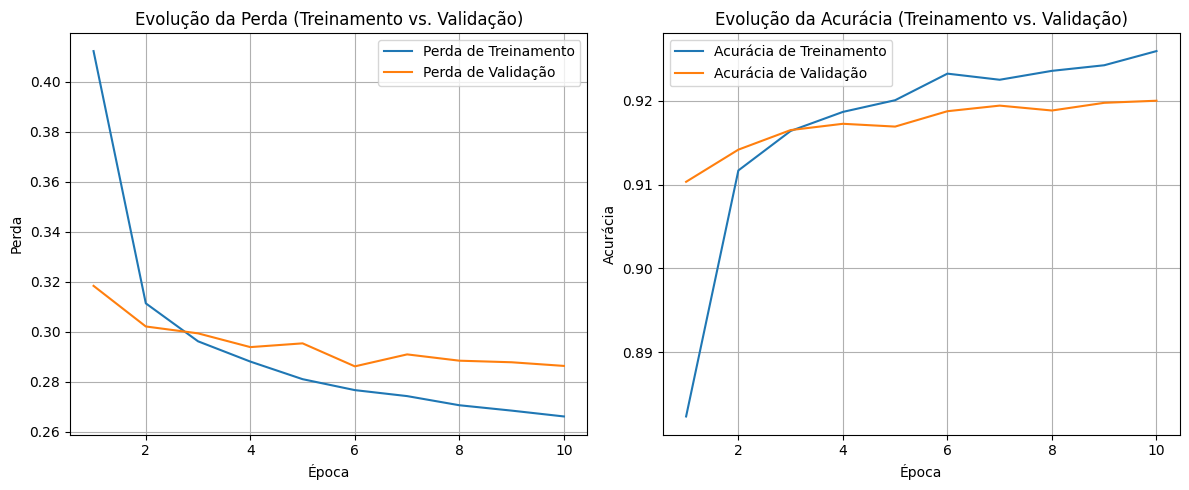

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
2. Em uma época, quantos mini-batches existem?
3. Qual é a definição de época?

Respostas:

1) 100 amostras (definido em batch_size = 100)
2) 480 batches (48.000 amostras de treino ÷ 100 por batch = 480 mini-batches por época
3) Uma época é uma passagem completa por todo o
conjunto de dados de treinamento. Ao final de uma época, o modelo viu todas as
amostras pelo menos uma vez

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

In [12]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        #####
        print(f'Época: {epoch+1}/{4}, batch: {(i+1)*batch_size}')
        #####
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Época: 1/4, batch: 100
Época: 1/4, batch: 200
Época: 1/4, batch: 300
Época: 1/4, batch: 400
Época: 1/4, batch: 500
Época: 1/4, batch: 600
Época: 1/4, batch: 700
Época: 1/4, batch: 800
Época: 1/4, batch: 900
Época: 1/4, batch: 1000
Época: 1/4, batch: 1100
Época: 1/4, batch: 1200
Época: 1/4, batch: 1300
Época: 1/4, batch: 1400
Época: 1/4, batch: 1500
Época: 1/4, batch: 1600
Época: 1/4, batch: 1700
Época: 1/4, batch: 1800
Época: 1/4, batch: 1900
Época: 1/4, batch: 2000
Época: 1/4, batch: 2100
Época: 1/4, batch: 2200
Época: 1/4, batch: 2300
Época: 1/4, batch: 2400
Época: 1/4, batch: 2500
Época: 1/4, batch: 2600
Época: 1/4, batch: 2700
Época: 1/4, batch: 2800
Época: 1/4, batch: 2900
Época: 1/4, batch: 3000
Época: 1/4, batch: 3100
Época: 1/4, batch: 3200
Época: 1/4, batch: 3300
Época: 1/4, batch: 3400
Época: 1/4, batch: 3500
Época: 1/4, batch: 3600
Época: 1/4, batch: 3700
Época: 1/4, batch: 3800
Época: 1/4, batch: 3900
Época: 1/4, batch: 4000
Época: 1/4, batch: 4100
Época: 1/4, batch: 4200
É


=== Treinando com batch_size = 10 ===
  Época 1/5 - Perda: 0.5551
  Época 2/5 - Perda: 0.4954
  Época 3/5 - Perda: 0.4855
  Época 4/5 - Perda: 0.4723
  Época 5/5 - Perda: 0.4671

=== Treinando com batch_size = 50 ===
  Época 1/5 - Perda: 0.3829
  Época 2/5 - Perda: 0.3097
  Época 3/5 - Perda: 0.2957
  Época 4/5 - Perda: 0.2884
  Época 5/5 - Perda: 0.2815

=== Treinando com batch_size = 100 ===
  Época 1/5 - Perda: 0.4096
  Época 2/5 - Perda: 0.3106
  Época 3/5 - Perda: 0.2944
  Época 4/5 - Perda: 0.2853
  Época 5/5 - Perda: 0.2789

=== Treinando com batch_size = 500 ===
  Época 1/5 - Perda: 0.5815
  Época 2/5 - Perda: 0.3738
  Época 3/5 - Perda: 0.3414
  Época 4/5 - Perda: 0.3250
  Época 5/5 - Perda: 0.3148


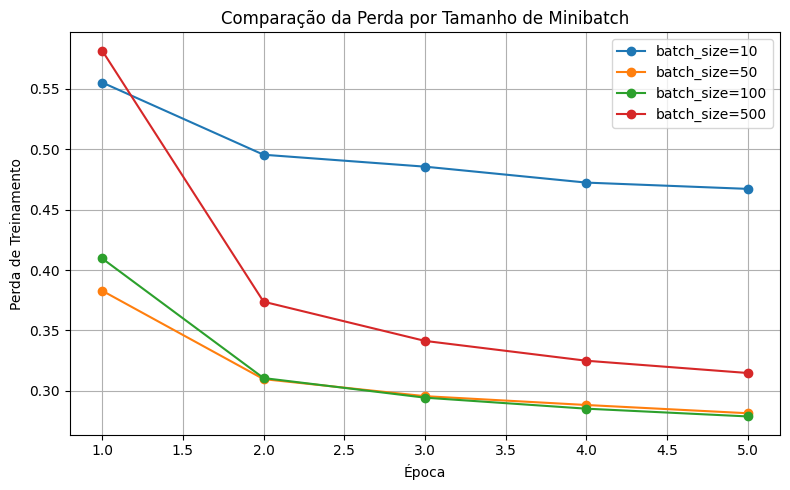

In [13]:
batch_sizes = [10, 50, 100, 500]
n_epochs = 5
learningRate = 0.5
dataset_dir = 'MNIST/'

all_train_losses = {}

for batch_size in batch_sizes:
    print(f'\n=== Treinando com batch_size = {batch_size} ===')

    full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                          transform=torchvision.transforms.ToTensor())
    train_size = int(0.8 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

    model = torch.nn.Linear(28*28, 10)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

    train_losses = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for x_train, y_train in loader_train:
            inputs = x_train.view(-1, 28 * 28)
            labels = y_train

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader_train)
        train_losses.append(avg_loss)
        print(f'  Época {epoch+1}/{n_epochs} - Perda: {avg_loss:.4f}')

    all_train_losses[batch_size] = train_losses

# Gráfico comparativo
plt.figure(figsize=(8, 5))
for batch_size, losses in all_train_losses.items():
    plt.plot(range(1, n_epochs + 1), losses, marker='o', label=f'batch_size={batch_size}')

plt.xlabel('Época')
plt.ylabel('Perda de Treinamento')
plt.title('Comparação da Perda por Tamanho de Minibatch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusões sobre os experimentos deste notebook


O gráfico mostra como diferentes valores de batch size influenciam o comportamento do treinamento da rede neural ao longo das épocas. Em todos os casos, observa-se a redução da perda (loss), indicando que o modelo está aprendendo corretamente.

Os resultados mostram que batch sizes menores, como 10, apresentam uma queda de perda mais lenta e irregular, pois as atualizações dos pesos são feitas com poucos exemplos por vez, tornando o treinamento mais ruidoso. Já valores intermediários, como 50 e 100, proporcionam uma convergência mais rápida e estável, alcançando menores valores de perda ao final do treinamento.

Por outro lado, o batch size de 500 gera uma curva mais suave, porém com convergência mais lenta em relação aos tamanhos intermediários. Isso acontece porque as atualizações dos pesos utilizam uma quantidade muito grande de dados de cada vez, reduzindo a frequência das correções realizadas pelo gradiente descendente.

Assim, o gráfico demonstra que existe um equilíbrio entre estabilidade e velocidade de aprendizado, sendo os batch sizes intermediários os que apresentaram melhor desempenho nesse experimento.